In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report as cr

# Load dataset (replace 'diabetes.csv' with your actual file)
df = pd.read_csv("diabetes.csv")  # Replace with your file path

# Assuming 'target' is the name of the column you're predicting
target = 'Outcome'  # Replace with your target column

# Separate features and target
x = df.drop([target], axis=1)
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

# Print train and test set shapes
print('Train set:', X_train.shape, y_train.shape)
print('Test set:', X_test.shape, y_test.shape)

# Define the number of neighbors
k = 5

# Train KNN models with different distance metrics
model_euclidean = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
model_euclidean.fit(X_train, y_train)

model_minkowski = KNeighborsClassifier(n_neighbors=k, metric='minkowski')  # Default p=2 for Euclidean-like behavior
model_minkowski.fit(X_train, y_train)

model_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
model_manhattan.fit(X_train, y_train)

# Evaluate models on the test set and print classification reports
print("For Euclidean:\n", cr(y_test, model_euclidean.predict(X_test)))
print("\n\nFor Minkowski:\n", cr(y_test, model_minkowski.predict(X_test)))
print("\n\nFor Manhattan:\n", cr(y_test, model_manhattan.predict(X_test)))


Train set: (614, 8) (614,)
Test set: (154, 8) (154,)
For Euclidean:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       102
           1       0.60      0.56      0.58        52

    accuracy                           0.73       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154



For Minkowski:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       102
           1       0.60      0.56      0.58        52

    accuracy                           0.73       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154



For Manhattan:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83       102
           1       0.68      0.58      0.62        52

    accuracy                           0.77       154
   macro avg       0.74

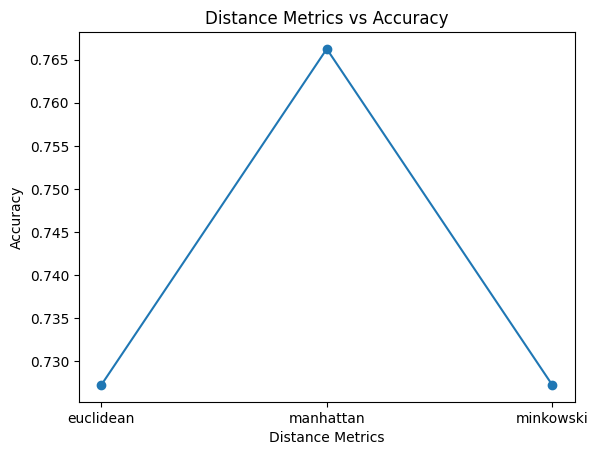

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as a_s

# Load data and prepare
df = pd.read_csv("diabetes.csv")  # Replace with your file path
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Train models and calculate accuracies
metrics = ['euclidean', 'manhattan', 'minkowski']
accuracies = [a_s(y_test, KNeighborsClassifier(n_neighbors=5, metric=m).fit(X_train, y_train).predict(X_test)) for m in metrics]

# Plot results
plt.plot(metrics, accuracies, marker='o')
plt.title("Distance Metrics vs Accuracy")
plt.xlabel("Distance Metrics")
plt.ylabel("Accuracy")
plt.show()


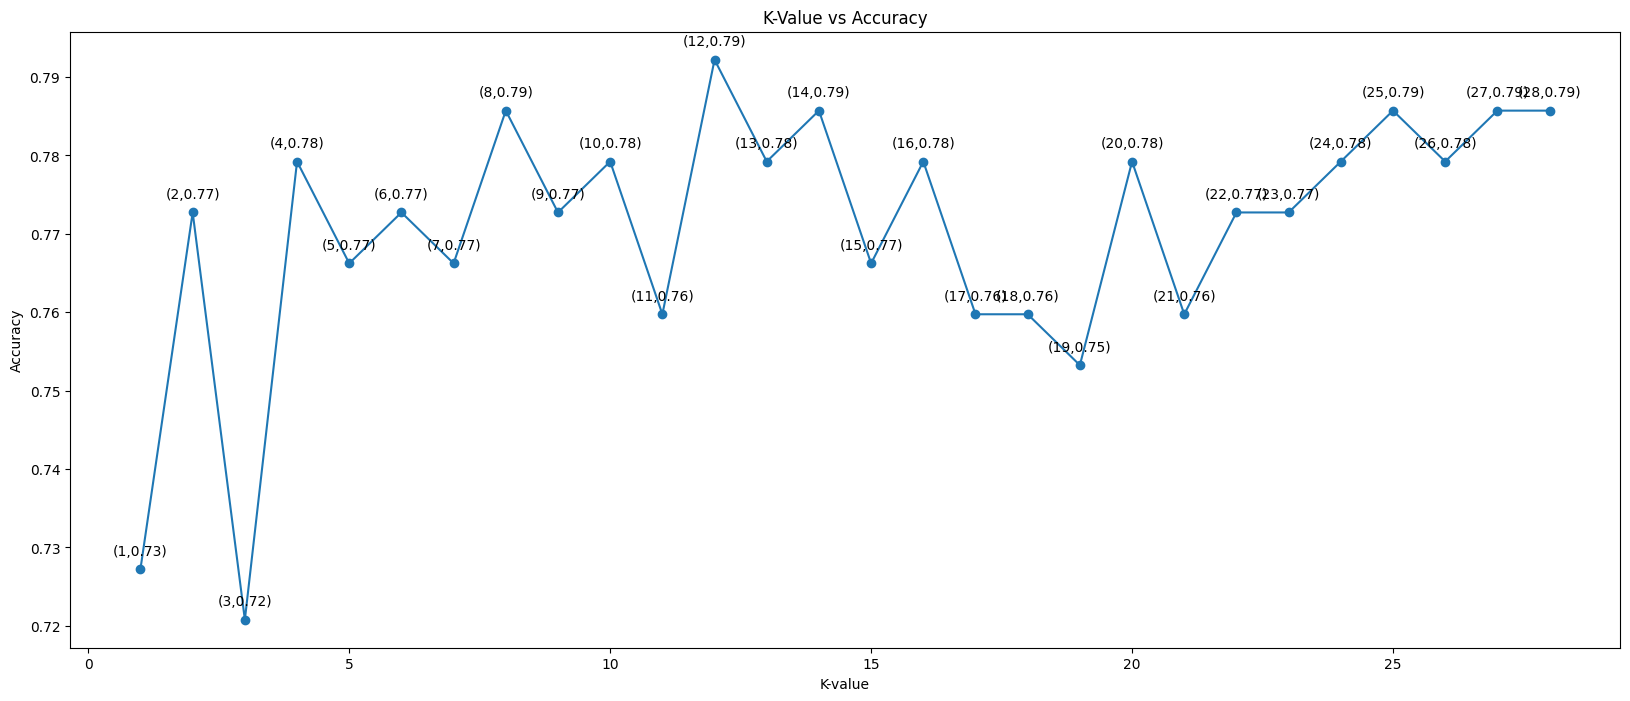

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as a_s

# Load data and prepare
df = pd.read_csv("diabetes.csv")  # Replace with your file path
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Calculate accuracies for different k-values (1 to 28)
k_values = range(1, 29)
accuracies = [a_s(y_test, KNeighborsClassifier(n_neighbors=k, metric='manhattan').fit(X_train, y_train).predict(X_test)) for k in k_values]

# Plot results with annotations
plt.figure(figsize=(20, 8))
plt.plot(k_values, accuracies, marker='o')
for i, acc in enumerate(accuracies):
    plt.annotate(f'({k_values[i]},{acc:.2f})', (k_values[i], acc), textcoords="offset points", xytext=(0, 10), ha='center')

plt.title("K-Value vs Accuracy")
plt.xlabel("K-value")
plt.ylabel("Accuracy")
plt.show()
